# Assignment 5 & 6: HRTEM Simulation and CTF Analysis - SOLUTIONS

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [1]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.0beta34


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

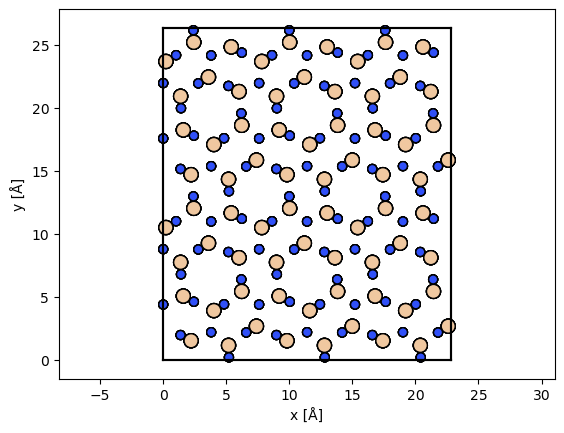

In [ ]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
structure_orthogonal = abtem.structures.orthogonalize_cell(structure)

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

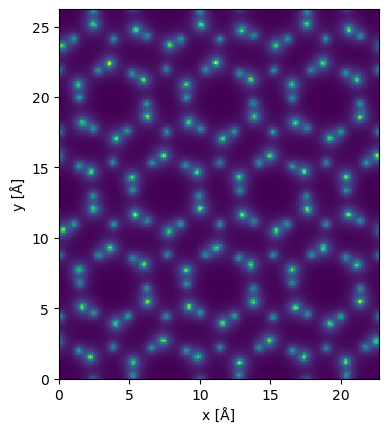

In [ ]:
# Create FrozenPhonons
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3,2,17),
    8,
    {'Si' : 0.1, 'N' : 0.1},
    seed=1,
)

# Create Potential
potential = abtem.Potential(
    frozen_phonons,
    sampling = 0.1,
    slice_thickness = 2.0,
    projection = 'infinite',
    parametrization = 'kirkland',
)

# Plot the projected potential
potential.project().show(cmap='viridis');

---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

TDS:   0%|          | 0/8 [00:00<?, ?it/s]

Multislice:   0%|          | 0/25 [00:00<?, ?it/s]

Potential:   0%|          | 0/25 [00:00<?, ?it/s]

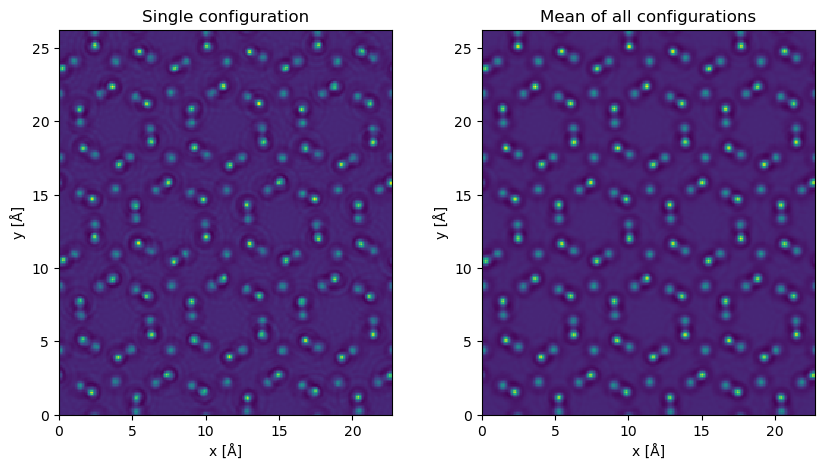

In [8]:
# Initialize PlaneWave
wave = abtem.PlaneWave(energy=300e3)

# Run multislice
exit_waves = wave.multislice(potential)

# Plot the mean intensity
fig, ax = plt.subplots(1, 2, figsize=(10,5))
exit_waves.show(ax=ax[0], cmap='viridis')
ax[0].set_title('Single configuration')
exit_waves.intensity().mean(0).show(ax=ax[1], cmap='viridis')
ax[1].set_title('Mean of all configurations');

---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

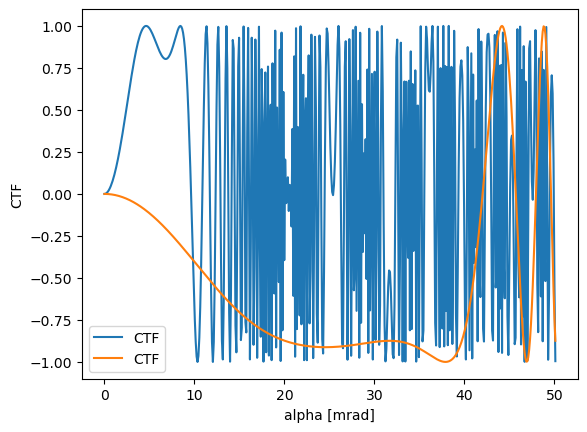

In [9]:
# Define uncorrected CTF parameters and create CTF object
parameters_uncorrected = {
    'C10': -600,
    'C30': 1.3e7,  # 1.3 mm
    'C50': 5e7,    # 5mm
}
ctf_uncorrected = abtem.CTF(energy=300e3, parameters=parameters_uncorrected)

# Define corrected CTF parameters and create CTF object
parameters_corrected = {
    'C10': 30,
    'C30': -8e4,
    'C50': 5e7,
}
ctf_corrected = abtem.CTF(energy=300e3, parameters=parameters_corrected)

# Plot the CTFs
fig, ax = plt.subplots()
ctf_uncorrected.show(ax=ax)
ctf_corrected.show(ax=ax);

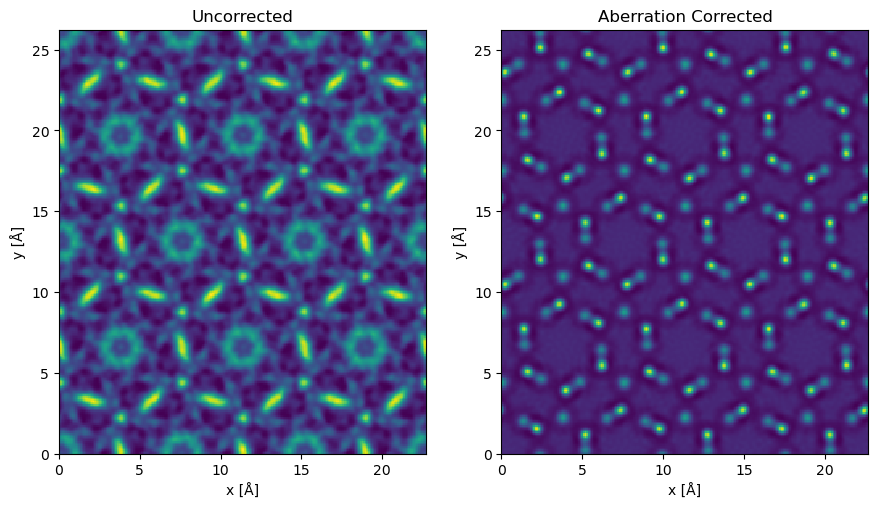

In [10]:
# Apply CTFs to exit waves
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected = exit_waves.apply_ctf(ctf_corrected)

# Plot the resulting images
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(9,5))

image_uncorrected.intensity().mean(0).show(
    cmap='viridis',
    ax=ax1
)
ax1.set_title('Uncorrected')

image_corrected.intensity().mean(0).show(
    cmap='viridis',
    ax=ax2
)
ax2.set_title('Aberration Corrected')

fig.tight_layout();

---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

In [11]:
from abtem.noise import poisson_noise

# Apply Poisson noise
dose = 100
intensity_corrected = image_corrected.intensity().mean(0)
noisy_image = poisson_noise(intensity_corrected, dose=dose)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,5))

intensity_corrected.show(ax=ax1, vmin=0, vmax=2.5, cmap='viridis')
ax1.set_title('Noiseless (Infinite Dose)')

noisy_image.show(ax=ax2, vmin=0, vmax=2.5, cmap='viridis')
ax2.set_title(f'Noisy (Dose = {dose} e-/Å²)')

fig.tight_layout();

AttributeError: module 'numpy' has no attribute 'product'

---

# Task 6: Self-Reflection (no need to submit)

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Solutions to Reflection Questions:

**1. Contrast Transfer Function (CTF):**
- **Difference in transfer:** The uncorrected CTF oscillates rapidly at higher spatial frequencies, meaning some frequencies are transferred with positive contrast, some with negative contrast, and some are completely lost (where CTF = 0). The aberration-corrected CTF maintains a flat, consistent phase transfer over a much wider range of spatial frequencies before oscillating.
- **Sharper columns:** Because the aberration-corrected CTF transfers high spatial frequencies (fine details) with the same phase as low frequencies, the information recombines constructively to form sharp, highly localized peaks at the atomic column positions (often called "white-atom contrast").

**2. Defocus and Contrast:**
- **Zero defocus:** At exactly zero defocus ($\Delta f = 0$), the phase shift from defocus is zero. For a thin phase object, the CTF is essentially zero at low spatial frequencies, meaning there is almost no amplitude contrast in the image. We need defocus to convert the phase shifts induced by the sample into observable amplitude variations.
- **Scherzer defocus:** The Scherzer defocus is the specific underfocus value that optimally balances the phase shift from spherical aberration ($C_s$) with the phase shift from defocus. This creates the widest possible "passband" where the CTF is nearly constant (usually near -1), maximizing the resolution of interpretable contrast.

**3. Simulation vs. Reality:**
- **Poisson noise:** Adding Poisson noise simulates the reality of a finite electron dose. It introduces statistical fluctuations that can obscure fine details, making it harder to distinguish true atomic columns from background noise, especially for light elements or low-dose conditions (like imaging beam-sensitive materials).
- **Other factors:** Real HRTEM images are degraded by sample drift, mechanical vibrations, objective lens current fluctuations (chromatic aberration), detector Point Spread Function (MTF/DQE), amorphous surface layers (e.g., oxidation or carbon contamination), and plural scattering from thicker regions.

**4. Multislice Algorithm:**
- **Necessity of multislice:** Even at 5 nm, dynamical diffraction (multiple scattering events) becomes significant. A single projected potential (kinematic approximation) assumes the electron wave only scatters once and doesn't change shape as it propagates. The multislice method accounts for the wave propagating and scattering multiple times through successive atomic layers, which is essential for accurately predicting the exit wave phase and amplitude in real crystals.